# Class 06 — Linear Regression: Simple & Multivariate

## Class Agenda

1. Simple linear regression — model and intuition
2. Least-squares estimator — derivation
3. Multivariate regression in matrix form
4. Normal equation and computational cost
5. Multicollinearity — diagnosis and remedies
6. Correlation vs causation
7. Hands-on: Boston/California housing

## Why This Topic Matters

**Importance in Machine Learning**  
Linear regression is the canonical model class used to teach optimisation, statistics, and interpretation — and remains a strong baseline.

**Importance in AI Systems**  
Many AI subsystems (ranking baselines, calibration, A/B uplift) ultimately rely on linear models for transparency.

**Importance in Production ML**  
Linear models dominate in regulated industries (credit, insurance, pharma) because every coefficient must be auditable.

**Importance in Interviews**  
Closed-form OLS, gradient form, and assumption violations are guaranteed interview questions.

**Real-World Relevance**  
Zillow Zestimate base layer, ad-bid pacing, and pharma dose–response models all use OLS variants.

## Learning Outcomes

By the end of this class, learners will be able to:

- Derive the OLS estimator from first principles
- Write the normal equation $\hat\beta=(X^\top X)^{-1}X^\top y$
- Interpret coefficients in original and standardised units
- Diagnose multicollinearity via VIF and condition number
- Detect heteroskedasticity and non-linearity from residual plots
- Compute prediction intervals
- Use QR/SVD instead of explicit inverse
- Compare gradient descent vs closed form by complexity
- Implement a leakage-free regression pipeline
- Quantify uncertainty using bootstrap
- Choose between OLS, Ridge, and robust regression

## 1. Simple Linear Regression

Model: $y_i=\beta_0+\beta_1 x_i+\varepsilon_i$ with $\varepsilon_i\stackrel{iid}{\sim}\mathcal N(0,\sigma^2)$.

Least-squares minimises $\text{SSE}=\sum(y_i-\beta_0-\beta_1 x_i)^2$. Setting partials to zero:

$$\hat\beta_1=\frac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2}=\frac{\text{Cov}(x,y)}{\text{Var}(x)},\qquad \hat\beta_0=\bar y-\hat\beta_1\bar x.$$

**Example.** $x{=}[1,2,3,4]$, $y{=}[2,4,5,4]$. $\bar x{=}2.5$, $\bar y{=}3.75$. Numerator $=(-1.5)(-1.75)+(-0.5)(0.25)+(0.5)(1.25)+(1.5)(0.25)=3.5$. Denominator $=5$. $\hat\beta_1=0.7$, $\hat\beta_0=2.0$.

In [ ]:
import numpy as np
x = np.array([1,2,3,4.]); y = np.array([2,4,5,4.])
b1 = np.cov(x,y, bias=True)[0,1]/np.var(x); b0 = y.mean()-b1*x.mean() #bias=True changes dividing factor from N-1 to N
print('b0,b1 =', b0, b1)

b0,b1 = 2.0 0.7


## 2. Multivariate Regression — Matrix Form

Stack: $y=X\beta+\varepsilon$ with $X\in\mathbb R^{n\times p}$ (intercept column of ones).

$$\widehat\beta=\arg\min_\beta \|y-X\beta\|_2^2=(X^\top X)^{-1}X^\top y.$$

**Derivation:** gradient $-2X^\top(y-X\beta)=0\Rightarrow X^\top X\beta=X^\top y$.

Complexity $\mathcal O(np^2 + p^3)$ — explicit inverse is *never* used in production; use QR ($\mathcal O(np^2)$) or SVD (numerically stable for ill-conditioned $X$).

**Example.** California Housing has $p=8$, $n=20{,}640$ — closed form runs in milliseconds.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

data = fetch_california_housing(as_frame=True)

Xtr, Xte, ytr, yte = train_test_split(
    data.data,
    data.target,
    test_size=0.2,
    random_state=0
)

pipe = Pipeline([
    ('sc', StandardScaler()),
    ('ols', LinearRegression())
])

pipe.fit(Xtr, ytr)

print(f'R² test = {pipe.score(Xte, yte):.3f}')

for name, c in zip(data.feature_names,
                   pipe.named_steps['ols'].coef_):
    print(f'{name:12s} {c:+.3f}')

R² test = 0.594
MedInc       +0.826
HouseAge     +0.117
AveRooms     -0.249
AveBedrms    +0.290
Population   -0.009
AveOccup     -0.031
Latitude     -0.900
Longitude    -0.871


## 3. Multicollinearity

When columns of $X$ are nearly linearly dependent, $X^\top X$ becomes near-singular: coefficients explode and flip sign with tiny data changes. Diagnostics:

- **Variance Inflation Factor**: $\text{VIF}_j=\frac1{1-R_j^2}$ where $R_j^2$ is the $R^2$ of regressing $x_j$ on the others. VIF > 5 (10) is concerning (severe).
- **Condition number** $\kappa(X)=\sigma_{\max}/\sigma_{\min}$; $\kappa>30$ signals collinearity.

**Example.** Including both `total_rooms` and `total_bedrooms` (correlation 0.93) inflates VIF >12. Solutions: drop one, use Ridge, or apply PCA.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import pandas as pd
Z = StandardScaler().fit_transform(data.data); Z = pd.DataFrame(Z, columns=data.feature_names)
print(pd.Series([vif(Z.values,i) for i in range(Z.shape[1])], index=Z.columns).round(2).sort_values(ascending=False))

Latitude      9.30
Longitude     8.96
AveRooms      8.34
AveBedrms     6.99
MedInc        2.50
HouseAge      1.24
Population    1.14
AveOccup      1.01
dtype: float64


## 4. Residual Diagnostics

Plot residuals vs fitted: should be a structureless cloud around zero. Patterns reveal:
- **Funnel** → heteroskedasticity (use robust SE or log-transform y).
- **Curve** → missing non-linearity (add polynomial or interaction).
- **Outliers** → use HuberRegressor or RANSAC.

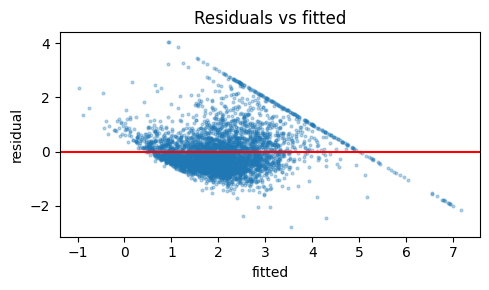

In [ ]:
import matplotlib.pyplot as plt
pred = pipe.predict(Xte); resid = yte - pred
plt.figure(figsize=(5,3)); plt.scatter(pred, resid, s=4, alpha=.3); plt.axhline(0, c='r'); plt.xlabel('fitted'); plt.ylabel('residual'); plt.title('Residuals vs fitted'); plt.tight_layout(); plt.show()

## Tradeoffs & Pitfalls
- OLS is **BLUE** under Gauss–Markov; violations of homoskedasticity invalidate SE.
- Sensitive to outliers — one leverage point can dominate.
- Extrapolation beyond training range is unreliable.

